In [1]:
import numpy as np
import pandas as pd
import os
import tweepy as tw

# 添加PySpark相关库
from pyspark.sql import SparkSession
from pyspark.ml.feature import Tokenizer, StopWordsRemover
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, StringType
#For Preprocessing
import re    # RegEx for removing non-letter characters
import nltk  #natural language processing
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.stem.porter import *

# For Building the model
from sklearn.model_selection import train_test_split
import tensorflow as tf
import seaborn as sns

#For data visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

pd.options.plotting.backend = "plotly"

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\CEasonK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
import numpy
print(numpy.__version__)

1.23.5


In [3]:
import numpy
print(numpy.__file__)

g:\python_twitter\Lib\site-packages\numpy\__init__.py


In [4]:
import os
import sys

# 检查并设置Python路径
python_path = sys.executable
print(f"Using Python at: {python_path}")

# 设置环境变量（必须放在SparkSession初始化之前）
os.environ['PYSPARK_PYTHON'] = python_path
os.environ['PYSPARK_DRIVER_PYTHON'] = python_path
os.environ['HADOOP_HOME'] = "D:\\VMware\\hadoop0\\hadoop-2.7.6\\hadoop-2.7.6"
os.environ['PATH'] += ";D:\\VMware\\hadoop0\\hadoop-2.7.6\\hadoop-2.7.6\\bin"

Using Python at: g:\python_twitter\Scripts\python.exe


In [5]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("TwitterSentimentAnalysis") \
    .config("spark.pyspark.python", "d:\\Python-learn\\Python\\python.exe") \
    .config("spark.pyspark.driver.python", "d:\\Python-learn\\Python\\python.exe") \
    .config("spark.hadoop.hadoop.home.dir", "D:\\VMware\\hadoop0\\hadoop-2.7.6\\hadoop-2.7.6") \
    .config("spark.hadoop.fs.file.impl", "org.apache.hadoop.fs.LocalFileSystem") \
    .config("spark.hadoop.fs.defaultFS", "file:///") \
    .config("spark.network.timeout", "60s") \
    .config("spark.python.worker.timeout", "60") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "15g") \
    .config("spark.python.worker.memory", "12g") \
    .config("spark.driver.maxResultSize", "15g") \
    .getOrCreate()

In [6]:

df1 = spark.read.csv("G:\\twitter-and-reddit-sentimental-analysis-dataset\\Twitter_Data.csv", 
                        header=True, 
                        inferSchema=True)
# 输出前五行
df1.show(5)

+--------------------+--------+
|          clean_text|category|
+--------------------+--------+
|when modi promise...|      -1|
|talk all the nons...|       0|
|what did just say...|       1|
|asking his suppor...|       1|
|answer who among ...|       1|
+--------------------+--------+
only showing top 5 rows



In [7]:
from pyspark.sql.functions import expr
# 使用PySpark加载Tweet数据集
df2 = spark.read.csv("G:\\twitter-and-reddit-sentimental-analysis-dataset\\apple-twitter-sentiment-texts.csv", 
                        header=True, 
                        inferSchema=True)

# 重命名列
df2 = df2.withColumnRenamed('text', 'clean_text') \
            .withColumnRenamed('sentiment', 'category')

# 映射category列的值
mapping_expr = "CASE WHEN category = -1 THEN -1.0 WHEN category = 0 THEN 0.0 WHEN category = 1 THEN 1.0 ELSE category END"
df2 = df2.withColumn('category', expr(mapping_expr))

# 输出前五行
df2.show(5)

+--------------------+--------+
|          clean_text|category|
+--------------------+--------+
|Wow. Yall needa s...|    -1.0|
|What Happened To ...|     0.0|
|Thank u @apple I ...|     1.0|
|The oddly uplifti...|    NULL|
|         $AAPL #aapl|    NULL|
+--------------------+--------+
only showing top 5 rows



In [8]:
# 使用PySpark加载Tweet数据集
df3 = spark.read.csv("G:\\twitter-and-reddit-sentimental-analysis-dataset\\finalSentimentdata2.csv", 
                        header=True, 
                        inferSchema=True)

# 重命名列
df3 = df3.withColumnRenamed('text', 'clean_text') \
            .withColumnRenamed('sentiment', 'category')

# 映射category列的值
mapping_expr = """
    CASE 
        WHEN category = 'sad' THEN -1.0
        WHEN category = 'anger' THEN -1.0
        WHEN category = 'fear' THEN -1.0
        WHEN category = 'joy' THEN 1.0
        ELSE category
    END
"""
df3 = df3.withColumn('category', expr(mapping_expr))

# 删除不需要的列
df3 = df3.drop('Unnamed: 0')

# 输出前五行
df3.show(5)

+----+--------+--------------------+
| _c0|category|          clean_text|
+----+--------+--------------------+
|3204|    -1.0|agree the poor in...|
|1431|     1.0|if only i could h...|
| 654|     1.0|will nature conse...|
|2530|    -1.0|"coronavirus disa...|
|2296|    -1.0|uk records lowest...|
+----+--------+--------------------+
only showing top 5 rows



In [9]:
# Load Tweet dataset using PySpark
df4 = spark.read.csv("G:\\twitter-and-reddit-sentimental-analysis-dataset\\Tweets.csv\\Tweets.csv", 
                        header=True, 
                        inferSchema=True)

# Rename columns
df4 = df4.withColumnRenamed('text', 'clean_text') \
            .withColumnRenamed('airline_sentiment', 'category')

# Map category values
mapping_expr = """
    CASE 
        WHEN category = 'negative' THEN -1.0
        WHEN category = 'neutral' THEN 0.0
        WHEN category = 'positive' THEN 1.0
        ELSE category
    END
"""
df4 = df4.withColumn('category', expr(mapping_expr))

# Select specific columns
df4 = df4.select('category', 'clean_text')

# Output first five rows
df4.show(5)

+--------+--------------------+
|category|          clean_text|
+--------+--------------------+
|     0.0|@VirginAmerica Wh...|
|     1.0|@VirginAmerica pl...|
|     0.0|@VirginAmerica I ...|
|    -1.0|"@VirginAmerica i...|
|    -1.0|@VirginAmerica an...|
+--------+--------------------+
only showing top 5 rows



In [10]:
# 首先确保所有DataFrame具有相同的列
df1 = df1.select('category', 'clean_text')
df2 = df2.select('category', 'clean_text')
df3 = df3.select('category', 'clean_text')
df4 = df4.select('category', 'clean_text')

# 现在可以安全地合并DataFrame
df = df1.union(df2).union(df3).union(df4)

In [11]:
df1.groupBy("category").count().show()
df2.groupBy("category").count().show()
df3.groupBy("category").count().show()
df4.groupBy("category").count().show()

+--------+-----+
|category|count|
+--------+-----+
|      -1|34665|
|    NULL|33437|
|       1|70476|
|       0|53553|
+--------+-----+

+-------------------+-----+
|           category|count|
+-------------------+-----+
|                1.0|  143|
|     I have a soul.|    1|
|               NULL|  191|
|                0.0|  798|
| anon is decimated"|    1|
|       keep flying"|    1|
|            #PayPal|    1|
|               -1.0|  685|
|         it's you."|    1|
+-------------------+-----+

+--------+-----+
|category|count|
+--------+-----+
|     1.0|  727|
|    -1.0| 2363|
+--------+-----+

+--------------------+-----+
|            category|count|
+--------------------+-----+
|[35.23185283, -80...|    1|
|   ubetter do smth!"|    1|
|                 1.0| 2363|
| we had a good ru...|    1|
| never submits. F...|    1|
|[40.7740308, -73....|    1|
|                   0|    8|
|     please????????"|    1|
|                NULL|  155|
| this is where Ce...|    1|
| flight AA1469 2/

In [12]:
# 检查缺失值
from pyspark.sql.functions import col, sum as spark_sum

df.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()


+--------+----------+
|category|clean_text|
+--------+----------+
|   33783|       209|
+--------+----------+



In [13]:
# 删除包含缺失值的行
df = df.na.drop()

In [14]:
# 获取数据的维度
row_count = df.count()
col_count = len(df.columns)
print(f"行数：{row_count}, 列数：{col_count}")


行数：178043, 列数：2


In [15]:
# 映射tweet类别
from pyspark.sql.functions import when

df = df.withColumn('category', 
                    when(df['category'] == -1.0, 'Negative')
                    .when(df['category'] == 0.0, 'Neutral')
                    .when(df['category'] == 1.0, 'Positive'))

# 输出前五行
df.show(5)

+--------+--------------------+
|category|          clean_text|
+--------+--------------------+
|Negative|when modi promise...|
| Neutral|talk all the nons...|
|Positive|what did just say...|
|Positive|asking his suppor...|
|Positive|answer who among ...|
+--------+--------------------+
only showing top 5 rows



## Exploratory Data Analysis
Data Visualisation-

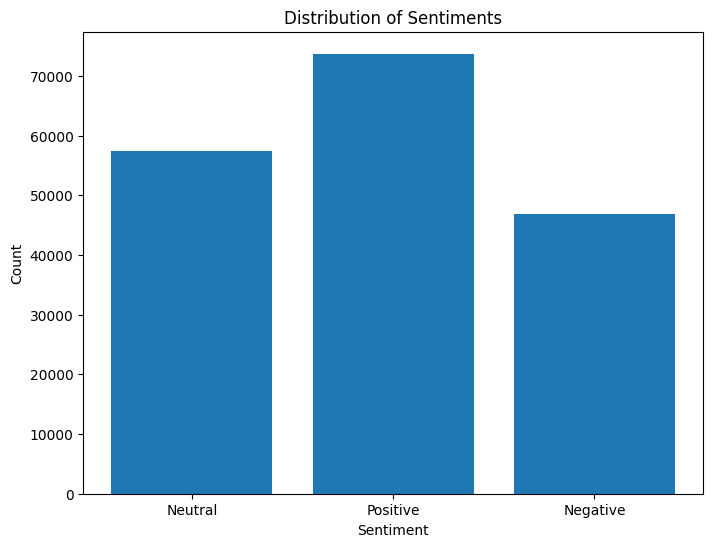

In [16]:
# 情感分布统计
import matplotlib.pyplot as plt

# 使用PySpark进行分组统计
sentiment_counts = df.groupBy('category').count().toPandas()

# 过滤掉None值并转换为字符串
sentiment_counts = sentiment_counts.dropna()
sentiment_counts['category'] = sentiment_counts['category'].astype(str)

# 使用Matplotlib绘制条形图
plt.figure(figsize=(8, 6))
plt.bar(sentiment_counts['category'], sentiment_counts['count'])
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Distribution of Sentiments')
plt.show()


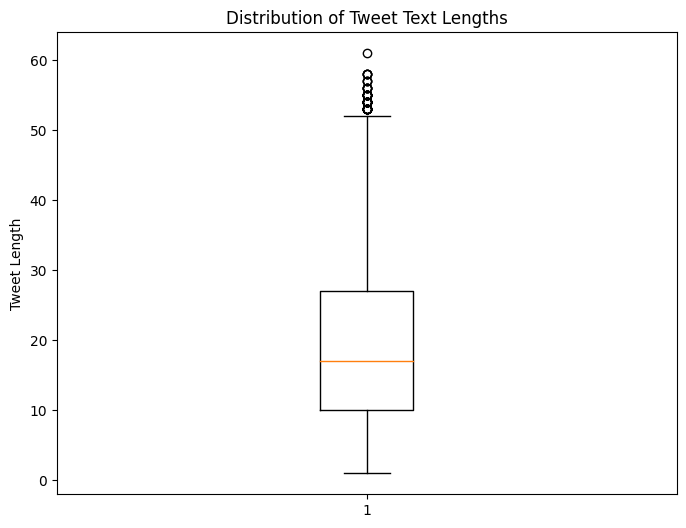

In [17]:
# 计算tweet长度
from pyspark.sql.functions import size, split

df = df.withColumn('tweet_len', size(split(df['clean_text'], ' ')))

# 将长度数据转换为Pandas DataFrame以便绘图
tweet_len = df.select('tweet_len').toPandas()['tweet_len']

# 使用Matplotlib绘制箱线图
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.boxplot(tweet_len)
plt.ylabel('Tweet Length')
plt.title('Distribution of Tweet Text Lengths')
plt.show()


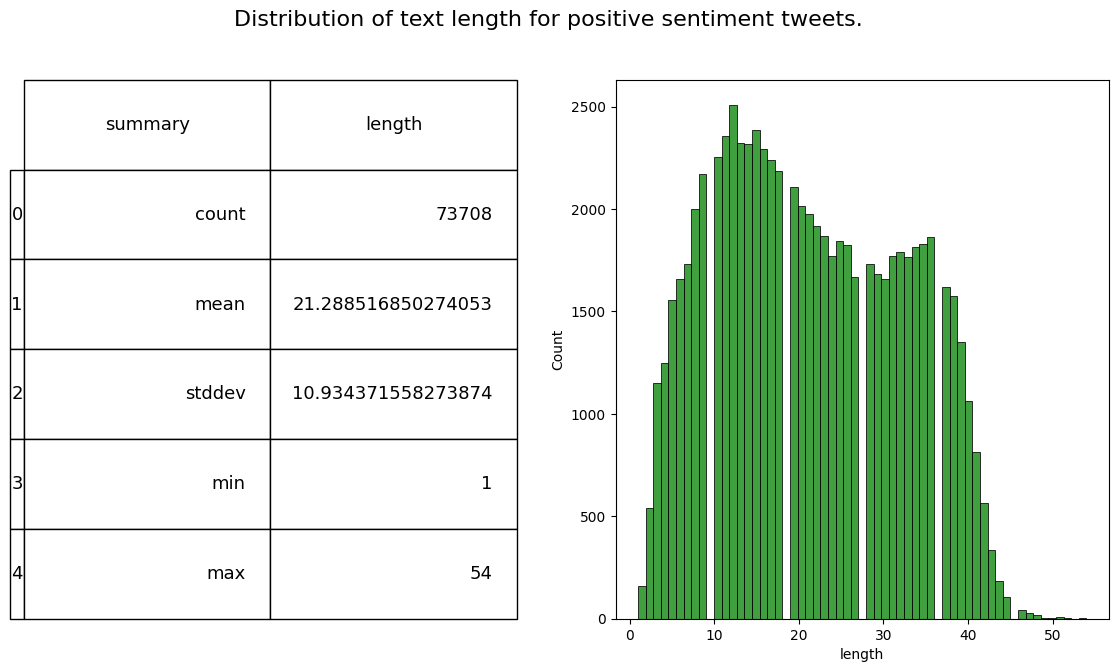

In [18]:
# 计算文本长度
from pyspark.sql.functions import size, split
df = df.withColumn('length', size(split(df['clean_text'], ' ')))

# 获取积极情感推文的长度数据
positive_df = df.filter(df['category'] == 'Positive')
positive_len = positive_df.select('length').toPandas()['length']

# 创建图表
fig = plt.figure(figsize=(14,7))

# 绘制直方图
ax1 = fig.add_subplot(122)
sns.histplot(positive_len, ax=ax1, color='green')

# 计算描述性统计
describe = positive_df.select('length').describe().toPandas().round(2)

# 添加统计表格
ax2 = fig.add_subplot(121)
ax2.axis('off')
font_size = 14
bbox = [0, 0, 1, 1]
table = ax2.table(cellText=describe.values, 
                    rowLabels=describe.index, 
                    bbox=bbox, 
                    colLabels=describe.columns)
table.set_fontsize(font_size)

# 设置图表标题
fig.suptitle('Distribution of text length for positive sentiment tweets.', fontsize=16)

plt.show()


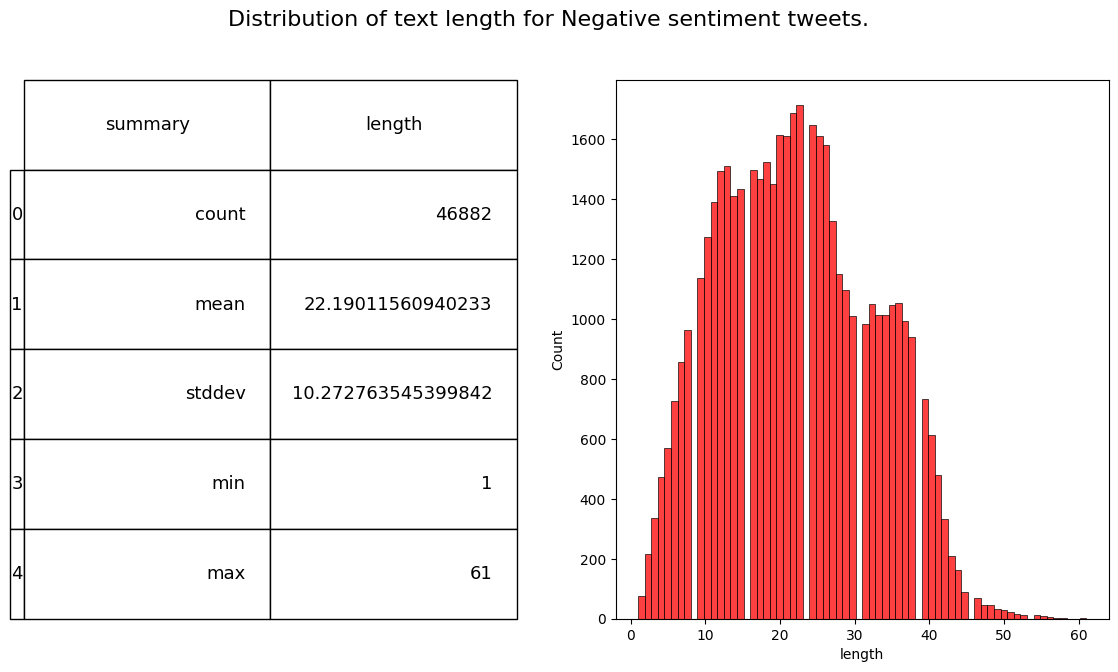

In [19]:
# 计算文本长度
from pyspark.sql.functions import size, split
df = df.withColumn('length', size(split(df['clean_text'], ' ')))

# 获取消极情感推文的长度数据
negative_df = df.filter(df['category'] == 'Negative')
negative_len = negative_df.select('length').toPandas()['length']

# 创建图表
fig = plt.figure(figsize=(14,7))

# 绘制直方图
ax1 = fig.add_subplot(122)
sns.histplot(negative_len, ax=ax1, color='red')

# 计算描述性统计
describe = negative_df.select('length').describe().toPandas().round(2)

# 添加统计表格
ax2 = fig.add_subplot(121)
ax2.axis('off')
font_size = 14
bbox = [0, 0, 1, 1]
table = ax2.table(cellText=describe.values, 
                    rowLabels=describe.index, 
                    bbox=bbox, 
                    colLabels=describe.columns)
table.set_fontsize(font_size)

# 设置图表标题
fig.suptitle('Distribution of text length for Negative sentiment tweets.', fontsize=16)

plt.show()


In [20]:
# 将Spark DataFrame转换为Pandas DataFrame以便使用Plotly
df_pd = df.groupBy('category').count().toPandas()

# 使用Plotly绘制饼图
import plotly.express as px
fig = px.pie(df_pd, values='count', names='category', title='Pie chart of different sentiments of tweets')
fig.show()


In [21]:
# 删除length列
df = df.drop('length')

# 输出前五行
df.show(5)


+--------+--------------------+---------+
|category|          clean_text|tweet_len|
+--------+--------------------+---------+
|Negative|when modi promise...|       33|
| Neutral|talk all the nons...|       14|
|Positive|what did just say...|       23|
|Positive|asking his suppor...|       34|
|Positive|answer who among ...|       15|
+--------+--------------------+---------+
only showing top 5 rows



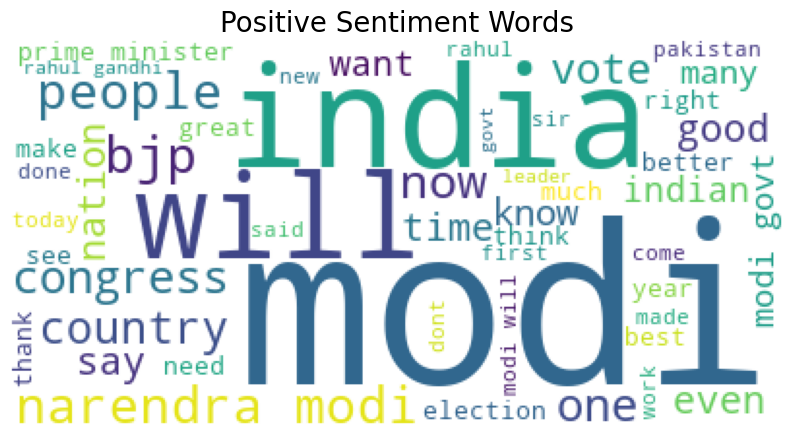

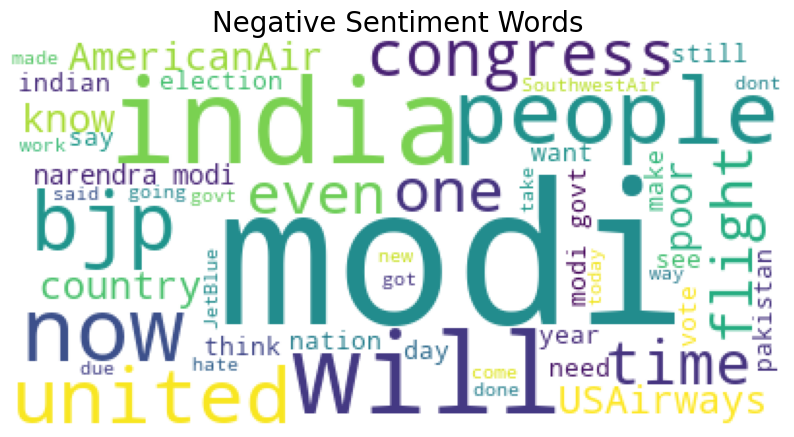

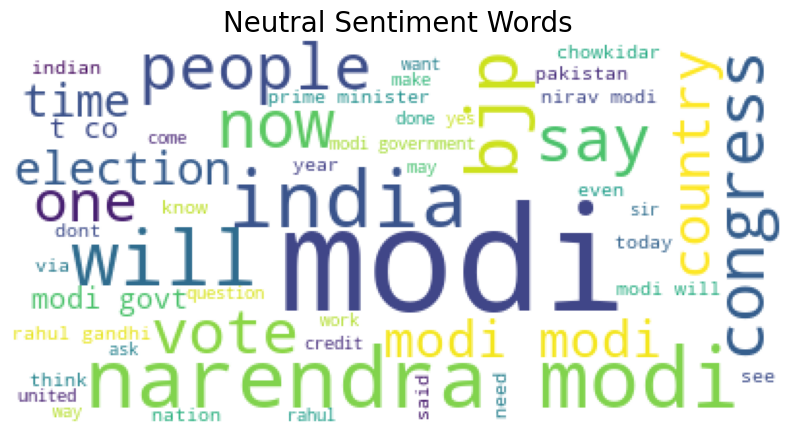

In [22]:
#### Visualizing data into wordclouds

from wordcloud import WordCloud, STOPWORDS

def wordcount_gen(df, category):
    '''
    Generating Word Cloud
    inputs:
        - df: tweets dataset
        - category: Positive/Negative/Neutral
    '''
    # 过滤指定类别的推文并转换为Pandas DataFrame
    filtered_df = df.filter(df.category == category).select('clean_text').toPandas()
    
    # 合并所有推文
    combined_tweets = " ".join(filtered_df['clean_text'])

    # 初始化词云对象
    wc = WordCloud(background_color='white', 
                    max_words=50, 
                    stopwords = STOPWORDS)

    # 生成并绘制词云
    plt.figure(figsize=(10,10))
    plt.imshow(wc.generate(combined_tweets))
    plt.title('{} Sentiment Words'.format(category), fontsize=20)
    plt.axis('off')
    plt.show()
    
# Positive tweet words
wordcount_gen(df, 'Positive')

# Negative tweet words
wordcount_gen(df, 'Negative')

# Neutral tweet words
wordcount_gen(df, 'Neutral')


In [23]:
import sys
print(sys.executable)

g:\python_twitter\Scripts\python.exe


In [24]:
from pyspark.sql import functions as F
# 检查 category 列中的空值数量
null_count = df.filter(F.col("category").isNull()).count()
print(f"category 列中的空值数量: {null_count}")

category 列中的空值数量: 5


In [25]:
df = df.na.drop(subset=["category"])

In [26]:
df = df.na.fill({"category": "Unknown"})

In [27]:
from pyspark.sql.functions import when

df = df.withColumn(
    "category",
    when(F.col("category").isNull(), "Neutral").otherwise(F.col("category"))
)

In [28]:
from pyspark.ml.feature import StringIndexer

# 配置 handleInvalid="skip" 或 "keep"
label_indexer = StringIndexer(inputCol="category", outputCol="indexed_label", handleInvalid="skip")
df = label_indexer.fit(df).transform(df)

# 查看结果
df.select("category", "indexed_label").show(5)

+--------+-------------+
|category|indexed_label|
+--------+-------------+
|Negative|          2.0|
| Neutral|          1.0|
|Positive|          0.0|
|Positive|          0.0|
|Positive|          0.0|
+--------+-------------+
only showing top 5 rows



In [29]:
# 查看所有列名和类型
df.printSchema()

# 或查看前几行数据
df.show(5)

root
 |-- category: string (nullable = false)
 |-- clean_text: string (nullable = true)
 |-- tweet_len: integer (nullable = false)
 |-- indexed_label: double (nullable = false)

+--------+--------------------+---------+-------------+
|category|          clean_text|tweet_len|indexed_label|
+--------+--------------------+---------+-------------+
|Negative|when modi promise...|       33|          2.0|
| Neutral|talk all the nons...|       14|          1.0|
|Positive|what did just say...|       23|          0.0|
|Positive|asking his suppor...|       34|          0.0|
|Positive|answer who among ...|       15|          0.0|
+--------+--------------------+---------+-------------+
only showing top 5 rows



In [30]:
from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType, StringType
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# 确保停用词已下载
import nltk
nltk.download('stopwords')

# 广播停用词（优化分布式环境性能）
stop_words = spark.sparkContext.broadcast(set(stopwords.words("english")))
stemmer = PorterStemmer()

# 定义UDF
def tweet_to_words(tweet):
    if not tweet:
        return []
    text = tweet.lower()
    text = re.sub(r"[^a-zA-Z0-9]", " ", text)
    words = text.split()
    words = [w for w in words if w not in stop_words.value]
    words = [stemmer.stem(w) for w in words]
    return words

# 注册UDF
tweet_to_words_udf = F.udf(tweet_to_words, ArrayType(StringType()))

# 测试单条数据处理
sample_row = df.select("clean_text").limit(1).collect()[0]
print("Original tweet ->", sample_row["clean_text"])
print("Processed tweet ->", tweet_to_words(sample_row["clean_text"]))

# 应用处理（生成新列）
df = df.withColumn("processed_text", tweet_to_words_udf(F.col("clean_text")))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\CEasonK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Original tweet -> when modi promised “minimum government maximum governance” expected him begin the difficult job reforming the state why does take years get justice state should and not business and should exit psus and temples
Processed tweet -> ['modi', 'promis', 'minimum', 'govern', 'maximum', 'govern', 'expect', 'begin', 'difficult', 'job', 'reform', 'state', 'take', 'year', 'get', 'justic', 'state', 'busi', 'exit', 'psu', 'templ']


In [31]:
# # 将数据转换为Pandas DataFrame进行处理
# df_pd = df.toPandas()
# X = list(map(tweet_to_words, df_pd['clean_text']))


In [32]:
# 查看所有列名和类型
df.printSchema()

# 或查看前几行数据
df.show(5)

root
 |-- category: string (nullable = false)
 |-- clean_text: string (nullable = true)
 |-- tweet_len: integer (nullable = false)
 |-- indexed_label: double (nullable = false)
 |-- processed_text: array (nullable = true)
 |    |-- element: string (containsNull = true)

+--------+--------------------+---------+-------------+--------------------+
|category|          clean_text|tweet_len|indexed_label|      processed_text|
+--------+--------------------+---------+-------------+--------------------+
|Negative|when modi promise...|       33|          2.0|[modi, promis, mi...|
| Neutral|talk all the nons...|       14|          1.0|[talk, nonsens, c...|
|Positive|what did just say...|       23|          0.0|[say, vote, modi,...|
|Positive|asking his suppor...|       34|          0.0|[ask, support, pr...|
|Positive|answer who among ...|       15|          0.0|[answer, among, p...|
+--------+--------------------+---------+-------------+--------------------+
only showing top 5 rows



In [33]:
# 打印 category 列的唯一值和数量
df.groupBy("category").count().show()

+--------+-----+
|category|count|
+--------+-----+
| Neutral|57448|
|Positive|73708|
|Negative|46882|
+--------+-----+



In [34]:
print("Columns in DataFrame:", df.columns)

Columns in DataFrame: ['category', 'clean_text', 'tweet_len', 'indexed_label', 'processed_text']


In [35]:
# 拆分数据集
train_df, temp_df = df.randomSplit([0.8, 0.2], seed=1)  # 初步拆分为训练集和临时集
val_df, test_df = temp_df.randomSplit([0.5, 0.5], seed=1)  # 将临时集进一步拆分为验证集和测试集

# 打印各数据集的大小
print(f"Train: {train_df.count()}, Val: {val_df.count()}, Test: {test_df.count()}")

Train: 142605, Val: 17708, Test: 17725


In [36]:
# 检查训练集、验证集和测试集的类别分布
train_df.groupBy("category").count().show()
val_df.groupBy("category").count().show()
test_df.groupBy("category").count().show()

+--------+-----+
|category|count|
+--------+-----+
| Neutral|46075|
|Positive|58969|
|Negative|37561|
+--------+-----+

+--------+-----+
|category|count|
+--------+-----+
| Neutral| 5628|
|Positive| 7326|
|Negative| 4754|
+--------+-----+

+--------+-----+
|category|count|
+--------+-----+
| Neutral| 5745|
|Positive| 7413|
|Negative| 4567|
+--------+-----+



In [37]:
from pyspark.ml.feature import CountVectorizer, IDF
from pyspark.sql import SparkSession

# 初始化 SparkSession（如果尚未初始化）
spark = SparkSession.builder \
    .appName("TextFeatureExtraction") \
    .getOrCreate()

# 假设 train_df 和 test_df 已经存在，并且包含 "processed_text" 列
# processed_text 列是一个数组列（ArrayType），例如 ["word1", "word2", ...]

# 设置词汇表大小
vocabulary_size = 5000

# 使用 CountVectorizer 提取词频特征
count_vectorizer = CountVectorizer(
    inputCol="processed_text",       # 输入列名
    outputCol="raw_features",        # 输出列名
    vocabSize=vocabulary_size,       # 最大词汇表大小
    minDF=2                          # 忽略出现次数小于 2 的词
)

# 拟合并转换训练数据
count_vectorizer_model = count_vectorizer.fit(train_df)
train_df = count_vectorizer_model.transform(train_df)

# 转换测试数据
test_df = count_vectorizer_model.transform(test_df)

# 如果需要 TF-IDF 特征，可以使用 IDF
idf = IDF(inputCol="raw_features", outputCol="features")
idf_model = idf.fit(train_df)

# 计算训练数据的 TF-IDF 特征
train_df = idf_model.transform(train_df)

# 计算测试数据的 TF-IDF 特征
test_df = idf_model.transform(test_df)

# 查看结果
train_df.select("processed_text", "raw_features", "features").show(5, truncate=False)

+----------------------------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|processed_text                                                                                                        |raw_features                                                                                                                               |features                                                                                                           

In [38]:
import os
import pickle
from pyspark.sql import functions as F
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.sql.types import ArrayType, IntegerType
from hdfs import InsecureClient
import tempfile

# 参数设置
max_words = 5000  # 最大词汇表大小
max_len = 100     # 序列的最大长度

# 假设 df 包含 "clean_text" 列，且数据已经加载到 DataFrame 中
# ======================================================================
# PySpark 文本处理流程
# ======================================================================

# 1. 分词（Tokenization）
tokenizer = Tokenizer(inputCol="clean_text", outputCol="tokens")
df = tokenizer.transform(df)

# 2. 去停用词（Stop Words Removal）
stop_words_remover = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")
df = stop_words_remover.transform(df)

# 3. 构建词汇表（CountVectorizer）
count_vectorizer = CountVectorizer(
    inputCol="filtered_tokens",
    outputCol="token_indices",
    vocabSize=max_words,
    minDF=2
)
count_vectorizer_model = count_vectorizer.fit(df)
df = count_vectorizer_model.transform(df)

# 获取 PySpark 生成的词汇表
vocabulary = count_vectorizer_model.vocabulary  # 这是需要保存的核心数据

# ======================================================================
# HDFS 保存操作（修复部分）
# ======================================================================

# HDFS 配置
hdfs_url = "http://192.168.230.129:50070/"  # NameNode Web UI
hdfs_client = InsecureClient(hdfs_url, user="root")

# 文件路径配置
hdfs_vocab_path = "/usr/local/spark/mycode/rdd/vocabulary.pkl"
local_vocab_path = os.path.join(tempfile.gettempdir(), "vocabulary.pkl")  # 跨平台临时路径

def save_and_validate_vocab(obj, path):
    """保存并验证词汇表对象"""
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    
    # 验证保存内容
    with open(path, "rb") as f:
        loaded = pickle.load(f)
        if not isinstance(loaded, list):
            raise ValueError("Saved vocabulary is not a list")
        print(f"词汇表验证通过（{len(loaded)} 个词汇）")

try:
    # 保存 PySpark 的词汇表（不再是 Keras Tokenizer）
    print("\n保存 PySpark 生成的词汇表:")
    save_and_validate_vocab(vocabulary, local_vocab_path)

    # 上传到 HDFS
    with open(local_vocab_path, "rb") as f:
        hdfs_client.write(hdfs_vocab_path, f, overwrite=True)
    print(f"词汇表已上传至 HDFS：{hdfs_vocab_path}")

except Exception as e:
    print(f"操作失败：{str(e)}")
    raise

# ======================================================================
# 其他处理保持不变
# ======================================================================

# 4. 定义 UDF 进行序列填充（Padding）
def pad_sequence(tokens, max_len, vocabulary):
    indices = [vocabulary.index(token) + 1 if token in vocabulary else 0 
               for token in tokens]
    return indices[:max_len] + [0] * (max_len - len(indices))

pad_sequence_udf = F.udf(
    lambda tokens: pad_sequence(tokens, max_len, vocabulary), 
    ArrayType(IntegerType())
)

df = df.withColumn("padded_sequences", pad_sequence_udf(F.col("filtered_tokens")))

# 显示结果
print('\n处理结果示例:')
df.select("clean_text", "padded_sequences").show(1, truncate=False)


保存 PySpark 生成的词汇表:
词汇表验证通过（5000 个词汇）
词汇表已上传至 HDFS：/usr/local/spark/mycode/rdd/vocabulary.pkl

处理结果示例:
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|clean_text                                                                                                                                                                                                        |padded_sequences                                                                                                                        

In [39]:
# from hdfs import InsecureClient
# import pickle
# 
# # HDFS 配置
# hdfs_url = "http://192.168.230.129:50070/"  # HDFS NameNode 的 Web UI 地址
# hdfs_client = InsecureClient(hdfs_url, user="root")  # 替换为你的 HDFS 用户名
# 
# # HDFS 目标路径
# hdfs_vocab_path = "/usr/local/spark/mycode/rdd/vocabulary.pkl"
# 
# # 本地临时路径
# local_vocab_path = "/tmp/vocabulary.pkl"
# 
# # 确保 vocabulary 是正确的 Tokenizer 对象
# from keras.preprocessing.text import Tokenizer
# 
# # 创建并训练 tokenizer
# tokenizer = Tokenizer()
# tokenizer.fit_on_texts(["example text", "another example"])
# 
# # 保存 vocabulary 到本地
# with open(local_vocab_path, "wb") as f:
#     pickle.dump(tokenizer, f)
# 
# print(f"Vocabulary saved locally at: {local_vocab_path}")
# 
# # 验证保存的文件内容
# with open(local_vocab_path, "rb") as f:
#     loaded_object = pickle.load(f)
#     print(f"Loaded object type: {type(loaded_object)}")
#     if not hasattr(loaded_object, 'texts_to_sequences'):
#         raise ValueError("The saved object is not a valid tokenizer.")
# 
# # 使用 hdfs 客户端上传到 HDFS
# try:
#     with open(local_vocab_path, "rb") as f:
#         hdfs_client.write(hdfs_vocab_path, f, overwrite=True)
#     print("Vocabulary uploaded to HDFS successfully.")
# except Exception as e:
#     print(f"Failed to upload vocabulary to HDFS. Error: {e}")

In [40]:
# print(f"Vocabulary type: {type(vocabulary)}")
# if not hasattr(vocabulary, 'texts_to_sequences'):
#     raise ValueError("The vocabulary object is not a valid tokenizer.")

In [41]:
# import os
# os.environ['HADOOP_HOME'] = "D:\\VMware\\hadoop0\\hadoop-2.7.6\\hadoop-2.7.6"
# os.environ['PATH'] += "D:\\VMware\\hadoop0\\hadoop-2.7.6\\hadoop-2.7.6\\bin"
# # 定义保存路径
# model_save_path = "G:/twitter-and-reddit-sentimental-analysis-dataset/model"
# 
# # 检查路径是否存在
# if os.path.exists(model_save_path):
#     print(f"Path '{model_save_path}' already exists. Overwriting...")
# else:
#     print(f"Path '{model_save_path}' does not exist. Creating...")
# 
# # 保存 CountVectorizerModel 到文件（强制覆盖）
# count_vectorizer_model.write().overwrite().save(model_save_path)
# 
# # 加载 CountVectorizerModel 从文件
# loaded_count_vectorizer_model = CountVectorizerModel.load(model_save_path)
# 
# # 测试加载的模型是否正常工作
# vocabulary = loaded_count_vectorizer_model.vocabulary
# print("Loaded Vocabulary:", vocabulary[:10])  # 打印前 10 个单词

In [42]:
from pyspark.ml.feature import StringIndexer

# 替换 pd.get_dummies 为 PySpark 的 StringIndexer（标签编码）
label_indexer = StringIndexer(inputCol="category", outputCol="label", handleInvalid="keep")
indexer_model = label_indexer.fit(df)  # 先fit得到indexer_model
df = indexer_model.transform(df)

# 打印标签映射以验证
label_mapping = indexer_model.labels
print("Label Mapping from StringIndexer:", label_mapping)  # 如 ['Positive', 'Neutral', 'Negative']

# 拆分数据集（保持与原代码相同的 80% train / 10% val / 10% test 比例）
train_df, temp_df = df.randomSplit([0.8, 0.2], seed=1)
val_df, test_df = temp_df.randomSplit([0.5, 0.5], seed=1)

# 打印数据集大小（PySpark 使用 count() 替代 shape）
print('Train Set ->', train_df.count(), 'rows')
print('Validation Set ->', val_df.count(), 'rows')
print('Test Set ->', test_df.count(), 'rows')

Label Mapping from StringIndexer: ['Positive', 'Neutral', 'Negative']
Train Set -> 142605 rows
Validation Set -> 17708 rows
Test Set -> 17725 rows


In [43]:
# 替换 Keras F1 计算函数为 PySpark 兼容的评估方式
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

def spark_f1_score(predictions):
    ''' 使用 PySpark 的 MulticlassClassificationEvaluator 计算 F1 Score '''
    evaluator = MulticlassClassificationEvaluator(
        labelCol="indexed_label",  # 根据你的实际标签列名修改
        predictionCol="prediction",
        metricName="f1"
    )
    return evaluator.evaluate(predictions)

In [44]:
# 在 PySpark 中运行以下代码
print(spark.sparkContext.master)

local[*]


In [45]:
# from elephas.spark_model import SparkModel
# from keras.models import Sequential
# from keras.layers import Embedding, Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense, Dropout
# from keras.optimizers import legacy as legacy_optimizers  # 导入legacy优化器
# from pyspark.sql import functions as F

# # 参数设置
# vocab_size = 200000
# embedding_size = 32
# max_len = 100
# epochs = 3
# learning_rate = 0.1
# momentum = 0.8

# # 统一训练集标签类型为整数
# train_df = train_df.withColumn("indexed_label", F.col("indexed_label").cast("integer"))

# # 合并训练集 RDD
# train_rdd = train_df.select("padded_sequences", "indexed_label").rdd.map(
#     lambda row: (row.padded_sequences, row.indexed_label)
# )

# # 使用legacy优化器中的SGD
# sgd = legacy_optimizers.SGD(learning_rate=learning_rate, momentum=momentum)  # 关键修改

# # 构建简化版模型
# model = Sequential()
# model.add(Embedding(vocab_size, embedding_size, input_length=max_len))
# model.add(Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'))
# model.add(MaxPooling1D(pool_size=2))
# model.add(Bidirectional(LSTM(32)))
# model.add(Dropout(0.4))
# model.add(Dense(3, activation='softmax'))

# # 编译模型
# model.compile(loss='sparse_categorical_crossentropy', 
#                 optimizer=sgd,  # 使用legacy优化器
#                 metrics=['sparse_categorical_accuracy'])

# # 创建SparkModel并训练
# spark_model = SparkModel(model, frequency='epoch', 
#                         mode='synchronous', num_workers=4)
# spark_model.fit(train_rdd, epochs=epochs, batch_size=64, verbose=1)

In [51]:
from elephas.spark_model import SparkModel
from tensorflow.keras.models import Sequential  # 使用 tensorflow.keras 而不是独立的 keras
from tensorflow.keras.layers import (Embedding, Conv1D, MaxPooling1D, 
                                   Bidirectional, LSTM, Dense, Dropout,
                                   BatchNormalization, Activation, SpatialDropout1D)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers.legacy import Adam  # 明确使用 legacy 优化器
from pyspark.sql import SparkSession, functions as F
import numpy as np



# 参数设置
vocab_size = 200000
embedding_size = 32
max_len = 100
epochs = 3
learning_rate = 0.001
batch_size = 64

# 数据预处理
train_df = train_df.withColumn("indexed_label", F.col("indexed_label").cast("integer"))

# 确保数据可序列化
train_rdd = train_df.select("padded_sequences", "indexed_label").rdd.map(
    lambda row: (row.padded_sequences.tolist() if isinstance(row.padded_sequences, np.ndarray) else row.padded_sequences,
                int(row.indexed_label))
)

# 模型构建
model = Sequential([
    Embedding(vocab_size, embedding_size, input_length=max_len),
    SpatialDropout1D(0.2),
    Conv1D(64, 3, padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(2),
    Conv1D(32, 5, padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(2),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

# 使用 legacy 优化器
optimizer = Adam(
    learning_rate=learning_rate,
    beta_1=0.9,
    beta_2=0.999
)

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=optimizer,
              metrics=['sparse_categorical_accuracy'])

# 创建 SparkModel
spark_model = SparkModel(
    model,
    frequency='epoch',
    mode='synchronous',
    num_workers=2,  # 减少 worker 数量以避免资源问题
    custom_objects={'optimizer': optimizer}
)

try:
    # 训练前验证数据
    sample = train_rdd.first()
    print(f"样本数据验证 - 输入类型: {type(sample[0])}, 长度: {len(sample[0])}, 标签类型: {type(sample[1])}")
    
    # 开始训练
    print(">>> 开始训练模型 <<<")
    spark_model.fit(train_rdd, epochs=epochs, batch_size=batch_size, verbose=1)
finally:
    spark.stop()

样本数据验证 - 输入类型: <class 'list'>, 长度: 100, 标签类型: <class 'int'>
>>> 开始训练模型 <<<
>>> Fit model


Py4JJavaError: An error occurred while calling z:org.apache.spark.api.python.PythonRDD.collectAndServe.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 1 in stage 107.0 failed 1 times, most recent failure: Lost task 1.0 in stage 107.0 (TID 323) (CEasonK-Laptop executor driver): org.apache.spark.SparkException: Python worker exited unexpectedly (crashed)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:612)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:594)
	at scala.runtime.AbstractPartialFunction.apply(AbstractPartialFunction.scala:38)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:789)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:766)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator.hasNext(PythonRunner.scala:525)
	at org.apache.spark.InterruptibleIterator.hasN

In [ ]:
# print(type(val_features_rdd))  # 应该是 pyspark.rdd.PipelinedRDD
# print(type(val_labels_rdd))    # 应该是 pyspark.rdd.PipelinedRDD


In [ ]:
# val_labels_rdd = val_labels_rdd.map(lambda x: int(x))


In [ ]:
# print(val_features_rdd.take(5))  # 查看前 5 条数据
# print(val_labels_rdd.take(5))    # 查看前 5 条数据


In [ ]:
# 训练结束后查看模型结构
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 100, 32)           6400000   
                                                                 
 spatial_dropout1d_1 (Spati  (None, 100, 32)           0         
 alDropout1D)                                                    
                                                                 
 conv1d_3 (Conv1D)           (None, 100, 64)           6208      
                                                                 
 batch_normalization_2 (Bat  (None, 100, 64)           256       
 chNormalization)                                                
                                                                 
 activation_2 (Activation)   (None, 100, 64)           0         
                                                                 
 max_pooling1d_3 (MaxPoolin  (None, 50, 64)           

In [ ]:

# 验证集处理（拆分特征和标签）
val_features_rdd = val_df.select("padded_sequences").rdd.map(lambda x: x[0])  # 提取特征列
val_labels_rdd = val_df.select("indexed_label").rdd.map(lambda x: x[0])       # 提取标签列
val_labels_rdd = val_labels_rdd.map(lambda x: int(x))


# 构造特征-标签对的 RDD
test_rdd = val_features_rdd.zip(val_labels_rdd)

In [ ]:

print(test_rdd.take(5))  
# 预期输出类似：
# [([20, 927, 196, ...], 2), ([20, 1, 204, ...], 2), ...]


[([20, 927, 196, 0, 1, 9, 4833, 0, 1394, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 2), ([20, 1, 204, 794, 20, 44, 287, 439, 19, 621, 1172, 20, 355, 391, 608, 0, 114, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 2), ([3304, 170, 0, 1641, 170, 1801, 638, 186, 212, 2263, 0, 895, 21, 279, 1693, 71, 0, 895, 14, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 2), ([0, 34

In [ ]:
# 拆分成两个独立的 RDD
test_features_rdd = test_rdd.map(lambda x: x[0])  # 只取 features
test_labels_rdd = test_rdd.map(lambda x: x[1])    # 只取 labels

# 评估模型先把 RDD 转换为列表
loss, accuracy = spark_model.evaluate(val_features_rdd.collect(), val_labels_rdd.collect())

print(f"Validation Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")


Validation Loss: 0.6684, Accuracy: 0.7620


In [ ]:
from hdfs import InsecureClient
from keras.models import Sequential
import os

# HDFS 配置
hdfs_url = "http://192.168.230.129:50070/"  # HDFS NameNode 的 Web UI 地址
hdfs_client = InsecureClient(hdfs_url, user="root")  # 替换为你的 HDFS 用户名

# HDFS 目标路径
hdfs_model_path = "/usr/local/spark/mycode/rdd/best_model.h5"

# 本地临时路径
local_model_path = "/tmp/best_model.h5"

# 保存模型到本地
model.save(local_model_path)
print("Model saved locally.")

# 使用 hdfs 客户端上传到 HDFS
try:
    with open(local_model_path, "rb") as f:
        hdfs_client.write(hdfs_model_path, f, overwrite=True)
    print("Model uploaded to HDFS successfully.")
except Exception as e:
    print(f"Failed to upload model to HDFS. Error: {e}")

G:\python_twitter\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning:

You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.



Model saved locally.
Model uploaded to HDFS successfully.


In [ ]:
from keras.models import load_model
import os

# HDFS 目标路径
hdfs_model_path = "hdfs://cyk000:9000/usr/local/spark/mycode/rdd/best_model.h5"

# 本地临时路径
local_model_path = "/tmp/best_model.h5"

# 从 HDFS 下载模型到本地
os.system(f"hdfs dfs -copyToLocal -f {hdfs_model_path} {local_model_path}")
print(f"Model downloaded from HDFS to: {local_model_path}")

# 加载模型
model = load_model(local_model_path)
print("Model loaded successfully.")


Model downloaded from HDFS to: /tmp/best_model.h5
Model loaded successfully.


In [ ]:
from hdfs import InsecureClient
import pickle
from pyspark.sql import SparkSession
from keras.models import load_model
from pyspark.sql.types import ArrayType, IntegerType
from pyspark.sql.functions import udf

# 启动 SparkSession
spark = SparkSession.builder.appName("SentimentAnalysis").getOrCreate()

# HDFS 配置
hdfs_url = "http://192.168.230.129:50070/"  # 替换为你的 NameNode 地址
hdfs_client = InsecureClient(hdfs_url, user="root")  # 替换为你的 HDFS 用户名

# HDFS 路径
hdfs_model_path = "/usr/local/spark/mycode/rdd/best_model.h5"
hdfs_vocab_path = "/usr/local/spark/mycode/rdd/vocabulary.pkl"

# 本地缓存路径
local_model_path = "/tmp/best_model.h5"
local_vocab_path = "/tmp/vocabulary.pkl"

# 从 HDFS 下载文件到本地
def download_from_hdfs(hdfs_path, local_path):
    try:
        # 下载文件
        hdfs_client.download(hdfs_path, local_path, overwrite=True)
        print(f"File downloaded from HDFS: {hdfs_path} -> {local_path}")
    except Exception as e:
        print(f"Failed to download {hdfs_path} from HDFS. Error: {e}")
        raise

# 下载模型和词汇表
download_from_hdfs(hdfs_model_path, local_model_path)
download_from_hdfs(hdfs_vocab_path, local_vocab_path)

# 加载词汇表
with open(local_vocab_path, "rb") as f:
    vocabulary = pickle.load(f)

# 验证加载的词汇表
print(f"Loaded vocabulary type: {type(vocabulary)}")
if not isinstance(vocabulary, list):
    raise ValueError("Loaded vocabulary is not a list")

# 加载模型
model = load_model(local_model_path)

# 定义序列化函数
def pad_sequence(tokens, max_len, vocabulary):
    indices = [vocabulary.index(token) + 1 if token in vocabulary else 0 for token in tokens]
    return indices[:max_len] + [0] * (max_len - len(indices))

# 示例数据
data = [
    ("I love this movie!",),
    ("I hate this product.",),
    ("It's okay, nothing special.",),
    ("This is the best day of my life!",),
    ("I am feeling very sad today.",),
    ("The weather is neither good nor bad.",)
]
df = spark.createDataFrame(data, ["text"])

# 预测函数（用于 mapPartitions）
def predict_partition(iterator):
    """每个分区加载一次模型"""
    sentiment_classes = ['Negative', 'Neutral', 'Positive']
    model = load_model(local_model_path)  # 只在分区内加载一次
    
    results = []
    for row in iterator:
        text = row["text"]
        tokens = text.split()  # 简单分词
        xt = pad_sequence(tokens, max_len=100, vocabulary=vocabulary)  # 使用保存的词汇表
        xt = [xt]  # 确保输入形状为 (1, max_len)
        yt = model.predict(xt).argmax(axis=1)
        results.append((text, sentiment_classes[yt[0]]))
    
    return iter(results)

# 使用 mapPartitions 进行分布式推理
result_df = df.rdd.mapPartitions(predict_partition).toDF(["text", "sentiment"])

# 显示结果
result_df.show(truncate=False)

File downloaded from HDFS: /usr/local/spark/mycode/rdd/best_model.h5 -> /tmp/best_model.h5
File downloaded from HDFS: /usr/local/spark/mycode/rdd/vocabulary.pkl -> /tmp/vocabulary.pkl
Loaded vocabulary type: <class 'list'>
+------------------------------------+---------+
|text                                |sentiment|
+------------------------------------+---------+
|I love this movie!                  |Negative |
|I hate this product.                |Positive |
|It's okay, nothing special.         |Neutral  |
|This is the best day of my life!    |Negative |
|I am feeling very sad today.        |Positive |
|The weather is neither good nor bad.|Negative |
+------------------------------------+---------+



In [ ]:
# 示例文本
test_text = "I love this movie!"

# 推理时的预处理逻辑
tokens = test_text.split()  # 简单分词
xt = pad_sequence(tokens, max_len=50, vocabulary=vocabulary)  # 使用保存的词汇表
print(f"Tokenized and padded input: {xt}")

Tokenized and padded input: [0, 147, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
from keras.models import load_model

# 加载模型
model = load_model(local_model_path)

# 打印模型摘要
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 100, 32)           6400000   
                                                                 
 spatial_dropout1d_1 (Spati  (None, 100, 32)           0         
 alDropout1D)                                                    
                                                                 
 conv1d_3 (Conv1D)           (None, 100, 64)           6208      
                                                                 
 batch_normalization_2 (Bat  (None, 100, 64)           256       
 chNormalization)                                                
                                                                 
 activation_2 (Activation)   (None, 100, 64)           0         
                                                                 
 max_pooling1d_3 (MaxPoolin  (None, 50, 64)           

In [ ]:
# 训练时的标签顺序
sentiment_classes = ['Negative', 'Neutral', 'Positive']

# 打印标签顺序以验证
print(f"Sentiment classes: {sentiment_classes}")

Sentiment classes: ['Negative', 'Neutral', 'Positive']


In [ ]:
import string

# 示例文本
test_text = "I love this movie!"

# 统一分词和预处理逻辑
tokens = test_text.lower().split()  # 统一转为小写
tokens = [token.strip(string.punctuation) for token in tokens if token.strip(string.punctuation)]  # 去除标点符号

# 使用保存的词汇表进行映射
xt = pad_sequence(tokens, max_len=50, vocabulary=vocabulary)
print(f"Tokenized and padded input: {xt}")

Tokenized and padded input: [0, 147, 0, 455, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
sample_val_feature = val_df.select("padded_sequences").first()[0]
print("验证集特征长度:", len(sample_val_feature))  # 应为 50

验证集特征长度: 50


In [ ]:
print("Input shape:", model.input_shape)   # 应输出 (None, 50)
print("Output shape:", model.output_shape) # 应输出 (None, 3)

Input shape: (None, 50)
Output shape: (None, 3)


In [ ]:
sample_label = train_df.select("indexed_label").first()[0]
print("Label value:", sample_label)  # 应为 0、1、2 等整数

Label value: 2.0


In [ ]:
# 检查特征
sample_feature = train_df.select("padded_sequences").first()[0]
print("Feature type:", type(sample_feature))  # 应为 <class 'list'>
print("Feature length:", len(sample_feature))  # 应为 max_len=50
print("Sample values:", sample_feature[:5])   # 如 [1, 267, 0, 27, 1779]

# 检查标签
sample_label = train_df.select("indexed_label").first()[0]
print("Label type:", type(sample_label))      # 应为 <class 'float'>
print("Label value:", sample_label)           # 如 2.0

Feature type: <class 'list'>
Feature length: 50
Sample values: [20, 14, 0, 0, 0]
Label type: <class 'int'>
Label value: 2


In [ ]:
spark = SparkSession.builder.getOrCreate()
print("PySpark Version:", spark.sparkContext.version)

PySpark Version: 3.5.1


In [ ]:
# spark.stop()